In [1]:
import pandas as pd                           # For working with data
pd.set_option("display.max_columns", None)    # Lets us see all columns of the data instead of just a preview
import geopandas as gpd                       # For working with spatial data
import numpy as np                            # For working with numbers
import matplotlib.pyplot as plt               # For making graphs
from datetime import date                     # For formatting dates
from PIL import Image                         # For getting and displaying images from links
import requests                               # For getting information from links
from io import BytesIO                        # For working with types of input and output

import seaborn as sns
import folium
from folium.plugins import HeatMap

In [87]:
end_date = "2026-01-31"
mos_data = gpd.read_file(f"https://api.globe.gov/search/v1/measurement/?protocols=mosquito_habitat_mapper&datefield=measuredDate&startdate=2018-01-01&enddate={end_date}&geojson=TRUE&sample=FALSE")
land_cover = gpd.read_file(f"https://api.globe.gov/search/v1/measurement/?protocols=land_covers&datefield=measuredDate&startdate=2018-01-01&enddate={end_date}&geojson=TRUE&sample=FALSE")

In [88]:
df = pd.DataFrame(mos_data)
df.to_csv("output.csv", index=False)

In [89]:
mos_data.head(10)

,countryCode,countryName,elevation,mosquitohabitatmapperAbdomenCloseupPhotoUrls,mosquitohabitatmapperBreedingGroundEliminated,mosquitohabitatmapperComments,mosquitohabitatmapperDataSource,mosquitohabitatmapperExtraData,mosquitohabitatmapperGenus,mosquitohabitatmapperGlobeTeams,mosquitohabitatmapperLarvaFullBodyPhotoUrls,mosquitohabitatmapperLarvaeCount,mosquitohabitatmapperLastIdentifyStage,mosquitohabitatmapperLocationAccuracyM,mosquitohabitatmapperLocationMethod,mosquitohabitatmapperMeasuredAt,mosquitohabitatmapperMeasurementElevation,mosquitohabitatmapperMeasurementLatitude,mosquitohabitatmapperMeasurementLongitude,mosquitohabitatmapperMosquitoAdults,mosquitohabitatmapperMosquitoEggCount,mosquitohabitatmapperMosquitoEggs,mosquitohabitatmapperMosquitoHabitatMapperId,mosquitohabitatmapperMosquitoPupae,mosquitohabitatmapperSpecies,mosquitohabitatmapperUserid,mosquitohabitatmapperWaterSource,mosquitohabitatmapperWaterSourcePhotoUrls,mosquitohabitatmapperWaterSourceType,organizationId,organizationName,protocol,siteId,siteName,geometry
0,USA,United States,59.3,null,false,null,GLOBE Observer App,LarvaeVisibleNo,null,NaN,null,0,null,29,automatic,2026-01-31 00:31:00,0,32.7151,-117.1295,null,null,null,50487,false,null,178205484,tree holes,https://data.globe.gov/system/photos/2026/01/3...,container: natural,17043304,United States of America Citizen Science,mosquito_habitat_mapper,409674,11SMS878197,POINT (-117.13018 32.715)
1,USA,United States,5.9,null,false,null,GLOBE Observer App,LarvaeVisibleYes,null,NaN,null,null,identify-photo-larva,18,automatic,2026-01-30 22:21:00,0,21.319,-158.024,null,null,null,50486,false,null,178278578,"plant husk (areca, coconut etc)",pending approval,container: natural,17043304,United States of America Citizen Science,mosquito_habitat_mapper,409671,04QFJ012577,POINT (-158.02421 21.3184)
2,BRA,Brazil,13.0,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,"[COLUNanoII, COLUNSLZ]",null,0,null,13,automatic,2026-01-29 14:17:00,0,-2.5462,-44.3257,null,null,null,50378,false,null,137422345,other,https://data.globe.gov/system/photos/2026/01/2...,container: artificial,17459532,Brazil Citizen Science,mosquito_habitat_mapper,373830,23MNT749185,POINT (-44.32625 -2.54662)
3,THA,Thailand,146.9,null,true,null,GLOBE Observer App,LarvaeVisibleYes,null,NaN,null,null,identify,null,manual,2026-01-26 08:17:00,0,16.3629,103.4308,null,null,null,50369,false,null,178884320,other,null,container: artificial,48451737,Anukoolnaree School,mosquito_habitat_mapper,409216,48QUD323097,POINT (103.42989 16.36267)
4,THA,Thailand,7.0,null,true,null,GLOBE Observer App,LarvaeVisibleYes,null,[GLOBE PCSHSTrang],null,30,identify-later,null,manual,2026-01-26 07:45:00,0,7.5552,99.5567,true,null,false,50360,true,null,132602739,tire,https://data.globe.gov/system/photos/2026/01/2...,container: artificial,163028,Princess Chulabhorn Science High School Trang,mosquito_habitat_mapper,210710,47NNJ614351,POINT (99.55658 7.55462)
5,THA,Thailand,145.9,null,true,null,GLOBE Observer App,LarvaeVisibleYes,null,NaN,https://data.globe.gov/system/photos/2026/01/2...,null,identify-photo-abdomen,null,manual,2026-01-26 01:30:00,0,16.3871,103.473,null,null,null,50358,false,null,178884320,"cement, metal or plastic tank",null,container: artificial,48451737,Anukoolnaree School,mosquito_habitat_mapper,409189,48QUD369123,POINT (103.47276 16.38648)
6,THA,Thailand,144.6,null,true,null,GLOBE Observer App,LarvaeVisibleYes,null,NaN,null,null,identify,null,manual,2026-01-26 08:13:00,0,16.4058,103.464,null,null,null,50364,false,null,178884320,"cement, metal or plastic tank",null,container: artificial,48451737,Anukoolnaree School,mosquito_habitat_mapper,409211,48QUD359144,POINT (103.46325 16.40539)
7,THA,Thailand,164.1,null,true,null,GLOBE Observer App,LarvaeVisibleYes,null,NaN,null,null,identify,null,manual,2026-01-26 08:15:00,0,16.3864,103.4284,null,null,null,50367,false,null,178884320,other,null,container: artificial,48451737,Anukoolnaree School,mosquito_habitat_mapper,409214,4

In [90]:
#data.head()
mos_data.shape

(47394, 35)

In [91]:
mos_data.columns

Index(['countryCode', 'countryName', 'elevation',
       'mosquitohabitatmapperAbdomenCloseupPhotoUrls',
       'mosquitohabitatmapperBreedingGroundEliminated',
       'mosquitohabitatmapperComments', 'mosquitohabitatmapperDataSource',
       'mosquitohabitatmapperExtraData', 'mosquitohabitatmapperGenus',
       'mosquitohabitatmapperGlobeTeams',
       'mosquitohabitatmapperLarvaFullBodyPhotoUrls',
       'mosquitohabitatmapperLarvaeCount',
       'mosquitohabitatmapperLastIdentifyStage',
       'mosquitohabitatmapperLocationAccuracyM',
       'mosquitohabitatmapperLocationMethod',
       'mosquitohabitatmapperMeasuredAt',
       'mosquitohabitatmapperMeasurementElevation',
       'mosquitohabitatmapperMeasurementLatitude',
       'mosquitohabitatmapperMeasurementLongitude',
       'mosquitohabitatmapperMosquitoAdults',
       'mosquitohabitatmapperMosquitoEggCount',
       'mosquitohabitatmapperMosquitoEggs',
       'mosquitohabitatmapperMosquitoHabitatMapperId',
       'mosquitohabi

In [ ]:
mos_data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 47394 entries, 0 to 47393
Data columns (total 35 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   countryCode                                    47308 non-null  str           
 1   countryName                                    47308 non-null  str           
 2   elevation                                      47394 non-null  str           
 3   mosquitohabitatmapperAbdomenCloseupPhotoUrls   47394 non-null  str           
 4   mosquitohabitatmapperBreedingGroundEliminated  47394 non-null  str           
 5   mosquitohabitatmapperComments                  47394 non-null  str           
 6   mosquitohabitatmapperDataSource                47394 non-null  str           
 7   mosquitohabitatmapperExtraData                 47394 non-null  str           
 8   mosquitohabitatmapperGenus                     4

In [ ]:
fl_Mos_data = mos_data[mos_data["countryName"] == "United States"].copy()
fl_Mos_data = fl_Mos_data.cx[-87.7:-79.6, 24.4:31.1]

In [9]:
fl_Mos_data

,countryCode,countryName,elevation,mosquitohabitatmapperAbdomenCloseupPhotoUrls,mosquitohabitatmapperBreedingGroundEliminated,mosquitohabitatmapperComments,mosquitohabitatmapperDataSource,mosquitohabitatmapperExtraData,mosquitohabitatmapperGenus,mosquitohabitatmapperGlobeTeams,mosquitohabitatmapperLarvaFullBodyPhotoUrls,mosquitohabitatmapperLarvaeCount,mosquitohabitatmapperLastIdentifyStage,mosquitohabitatmapperLocationAccuracyM,mosquitohabitatmapperLocationMethod,mosquitohabitatmapperMeasuredAt,mosquitohabitatmapperMeasurementElevation,mosquitohabitatmapperMeasurementLatitude,mosquitohabitatmapperMeasurementLongitude,mosquitohabitatmapperMosquitoAdults,mosquitohabitatmapperMosquitoEggCount,mosquitohabitatmapperMosquitoEggs,mosquitohabitatmapperMosquitoHabitatMapperId,mosquitohabitatmapperMosquitoPupae,mosquitohabitatmapperSpecies,mosquitohabitatmapperUserid,mosquitohabitatmapperWaterSource,mosquitohabitatmapperWaterSourcePhotoUrls,mosquitohabitatmapperWaterSourceType,organizationId,organizationName,protocol,siteId,siteName,geometry
941,USA,United States,14.0,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,NaN,null,0,null,23,automatic,2025-11-04 17:41:00,0,30.5089,-86.5028,null,null,null,49205,false,null,159641339,jar,https://data.globe.gov/system/photos/2025/11/0...,container: artificial,17043304,United States of America Citizen Science,mosquito_habitat_mapper,403045,16REU477752,POINT (-86.50288 30.50815)
942,USA,United States,14.0,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,NaN,null,0,null,null,manual,2025-11-04 20:38:00,0,30.5088,-86.5028,null,null,null,49206,false,null,159641339,jar,https://data.globe.gov/system/photos/2025/11/0...,container: artificial,17043304,United States of America Citizen Science,mosquito_habitat_mapper,403045,16REU477752,POINT (-86.50288 30.50815)
1282,USA,United States,2.8,null,false,Canal in City running from inland to ocean.,GLOBE Observer App,LarvaeVisibleNo,null,NaN,null,0,null,20,automatic,2025-10-08 12:15:00,0,26.2154,-80.2169,null,null,null,48840,false,null,171829152,"puddle or still water next to a creek, stream ...",null,flowing: still water found next to river or st...,10532858,GLOBE Implementation Office GLOBE v-School,mosquito_habitat_mapper,400104,17RNJ782997,POINT (-80.21719 26.21473)
3160,USA,United States,3.5,null,false,null,GLOBE Observer App,LarvaeVisibleNo,null,NaN,null,0,null,31,automatic,2025-03-12 18:24:00,0,28.3521,-80.6053,null,null,null,46774,false,null,148137248,plant clumps (bamboo etc),https://data.globe.gov/system/photos/2025/03/1...,container: natural,17043304,United States of America Citizen Science,mosquito_habitat_mapper,380362,17RNM386362,POINT (-80.60613 28.35146)
3171,USA,United States,43.6,null,true,null,GLOBE Observer App,LarvaeVisibleYes,null,NaN,null,12,identify,12,automatic,2025-03-07 18:41:00,0,28.2852,-81.6414,true,null,false,46775,true,null,36036190,estuary,null,flowing: still water found next to river or st...,10532858,GLOBE Implementation Office GLOBE v-School,mosquito_habitat_mapper,380476,17RMM371289,POINT (-81.64142 28.28463)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42494,USA,United States,25.4,null,false,null,GLOBE Observer App,null,null,NaN,null,null,null,NaN,NaN,2018-12-29 21:38:00,0,28.1411,-82.4335,null,null,null,6217,false,null,2521381,fountain or bird bath,null,container: artificial,394556,University Of Toledo,mosquito_habitat_mapper,143714,17RLM592136,POINT (-82.4338 28.14052)
42495,USA,United States,25.4,null,true,null,GLOBE Observer App,null,null,NaN,null,3,identify,NaN,NaN,2018-12-29 22:30:00,0,28.1408,-82.4334,false,null,true,6220,true,null,51180976,can or bottle,https://data.globe.gov/system/photos/2018/12/2...,container: artificial,51181115,Graves Elementary,mosquito_habitat_mapper,143718,17RLM592136,POINT (-82.4338 28.14052)
45208,USA,United States,6.5,null,true,null,GLOBE Observer App,null,null,NaN,https://data.glob

In [10]:
fl_Mos_data.shape

(625, 35)

In [11]:
fl_landcover = land_cover[
    (land_cover["countryCode"] == "USA") & (land_cover.geometry.x.between(-87.7, -79.6)) & (land_cover.geometry.y.between(24.4, 31.1))
].copy()

In [12]:
fl_landcover.shape

(690, 63)

In [13]:
fl_landcover

,countryCode,countryName,elevation,landcoversDataSource,landcoversDownwardCaption,landcoversDownwardExtraData,landcoversDownwardPhotoUrl,landcoversDryGround,landcoversEastCaption,landcoversEastClassifications,landcoversEastExtraData,landcoversEastPhotoUrl,landcoversFeature1Caption,landcoversFeature1ExtraData,landcoversFeature1PhotoUrl,landcoversFeature2Caption,landcoversFeature2ExtraData,landcoversFeature2PhotoUrl,landcoversFeature3Caption,landcoversFeature3ExtraData,landcoversFeature3PhotoUrl,landcoversFeature4Caption,landcoversFeature4ExtraData,landcoversFeature4PhotoUrl,landcoversFieldNotes,landcoversGlobeTeams,landcoversLandCoverId,landcoversLeavesOnTrees,landcoversLocationAccuracyM,landcoversLocationMethod,landcoversMeasuredAt,landcoversMeasurementElevation,landcoversMeasurementLatitude,landcoversMeasurementLongitude,landcoversMucCode,landcoversMucDescription,landcoversMucDetails,landcoversMuddy,landcoversNorthCaption,landcoversNorthClassifications,landcoversNorthExtraData,landcoversNorthPhotoUrl,landcoversRainingSnowing,landcoversSnowIce,landcoversSouthCaption,landcoversSouthClassifications,landcoversSouthExtraData,landcoversSouthPhotoUrl,landcoversStandingWater,landcoversUpwardCaption,landcoversUpwardExtraData,landcoversUpwardPhotoUrl,landcoversUserid,landcoversWestCaption,landcoversWestClassifications,landcoversWestExtraData,landcoversWestPhotoUrl,organizationId,organizationName,protocol,siteId,siteName,geometry
602,USA,United States,51.2,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/01/0...,true,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 231, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 312, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 314, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,Standing decidusous broadleaf trees,"((compassData.heading: 169, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,Cutdown trees to west.,"[HTLC, OpeningTheAperture EarthAsArt, Oregon H...",88833,true,5,automatic,2026-01-02 19:47:00.000,48.3,28.6467,-81.7105,null,null,,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,null,null,https://data.globe.gov/system/photos/2026/01/0...,8267248,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,32402168,"College of Earth, Ocean, Atmospheric Sciences ...",land_covers,407606,17RMM305690,POINT (-81.71114 28.64624)
606,USA,United States,41.4,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/01/0...,true,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 287, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 67, compassData.horizon...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 155, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 227, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,Observation tower at tree canopy height. Everg...,"[HTLC, OpeningTheAperture EarthAsArt, Oregon H...",88836,true,5,automatic,2026-01-02 19:34:00.000,34.7,28.6474,-81.7085,null,null,,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,null,null,https://data.globe.gov/system/photos/2026/01/0...,8267248,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,32402168,"College of Earth, Ocean, Atmospheric Sciences ...",land_covers,407608,17RMM307691,POINT (-81.7091 28.64716)
607,USA,United States,41.4,GLOBE Observer App,null,null,null,true,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Duplicate location with

In [14]:
fl_merged_data = pd.merge(fl_landcover, fl_Mos_data, on="siteId")

In [15]:
fl_merged_data.shape

(178, 97)

In [16]:
fl_merged_data

,countryCode_x,countryName_x,elevation_x,landcoversDataSource,landcoversDownwardCaption,landcoversDownwardExtraData,landcoversDownwardPhotoUrl,landcoversDryGround,landcoversEastCaption,landcoversEastClassifications,landcoversEastExtraData,landcoversEastPhotoUrl,landcoversFeature1Caption,landcoversFeature1ExtraData,landcoversFeature1PhotoUrl,landcoversFeature2Caption,landcoversFeature2ExtraData,landcoversFeature2PhotoUrl,landcoversFeature3Caption,landcoversFeature3ExtraData,landcoversFeature3PhotoUrl,landcoversFeature4Caption,landcoversFeature4ExtraData,landcoversFeature4PhotoUrl,landcoversFieldNotes,landcoversGlobeTeams,landcoversLandCoverId,landcoversLeavesOnTrees,landcoversLocationAccuracyM,landcoversLocationMethod,landcoversMeasuredAt,landcoversMeasurementElevation,landcoversMeasurementLatitude,landcoversMeasurementLongitude,landcoversMucCode,landcoversMucDescription,landcoversMucDetails,landcoversMuddy,landcoversNorthCaption,landcoversNorthClassifications,landcoversNorthExtraData,landcoversNorthPhotoUrl,landcoversRainingSnowing,landcoversSnowIce,landcoversSouthCaption,landcoversSouthClassifications,landcoversSouthExtraData,landcoversSouthPhotoUrl,landcoversStandingWater,landcoversUpwardCaption,landcoversUpwardExtraData,landcoversUpwardPhotoUrl,landcoversUserid,landcoversWestCaption,landcoversWestClassifications,landcoversWestExtraData,landcoversWestPhotoUrl,organizationId_x,organizationName_x,protocol_x,siteId,siteName_x,geometry_x,countryCode_y,countryName_y,elevation_y,mosquitohabitatmapperAbdomenCloseupPhotoUrls,mosquitohabitatmapperBreedingGroundEliminated,mosquitohabitatmapperComments,mosquitohabitatmapperDataSource,mosquitohabitatmapperExtraData,mosquitohabitatmapperGenus,mosquitohabitatmapperGlobeTeams,mosquitohabitatmapperLarvaFullBodyPhotoUrls,mosquitohabitatmapperLarvaeCount,mosquitohabitatmapperLastIdentifyStage,mosquitohabitatmapperLocationAccuracyM,mosquitohabitatmapperLocationMethod,mosquitohabitatmapperMeasuredAt,mosquitohabitatmapperMeasurementElevation,mosquitohabitatmapperMeasurementLatitude,mosquitohabitatmapperMeasurementLongitude,mosquitohabitatmapperMosquitoAdults,mosquitohabitatmapperMosquitoEggCount,mosquitohabitatmapperMosquitoEggs,mosquitohabitatmapperMosquitoHabitatMapperId,mosquitohabitatmapperMosquitoPupae,mosquitohabitatmapperSpecies,mosquitohabitatmapperUserid,mosquitohabitatmapperWaterSource,mosquitohabitatmapperWaterSourcePhotoUrls,mosquitohabitatmapperWaterSourceType,organizationId_y,organizationName_y,protocol_y,siteName_y,geometry_y
0,USA,United States,2.8,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2025/10/0...,false,null,"10% MUC 01 (b) [Trees, Closely Spaced, Evergre...",null,https://data.globe.gov/system/photos/2025/10/0...,null,null,null,null,null,null,null,null,null,null,null,null,House and yard on canal,NaN,86094,true,null,manual,2025-10-05 22:55:00,2,26.2152,-80.2169,M91,"Urban, Residential Property",,false,null,"10% MUC 02 (n) [Trees, Closely Spaced, Deciduo...",null,https://data.globe.gov/system/photos/2025/10/0...,false,false,null,"30% MUC 01 (b) [Trees, Closely Spaced, Evergre...",null,https://data.globe.gov/system/photos/2025/10/0...,false,null,null,https://data.globe.gov/system/photos/2025/10/0...,171829152,null,"10% MUC 01 (b) [Trees, Closely Spaced, Evergre...",null,https://data.globe.gov/system/photos/2025/10/0...,10532858,GLOBE Implementation Office GLOBE v-School,land_covers,400104,17RNJ782997,POINT (-80.21719 26.21473),USA,United States,2.8,null,false,Canal in City running from inland to ocean.,GLOBE Observer App,LarvaeVisibleNo,null,NaN,null,0,null,20,automatic,2025-10-08 12:15:00,0,26.2154,-80.2169,null,null,null,48840,false,null,171829152,"puddle or still water next to a creek, stream ...",null,flowing: still water found next to river or st...,10532858,GLOBE Implementation Office GLOBE v-School,mosquito_habitat_mapper,17RNJ782997,POINT (-80.21719 26.21473)
1,USA,United States,6.4,GLOBE Observer App,null,null,https://data.globe.gov/system/photo

In [17]:
fl = fl_merged_data.copy()

In [18]:
fl.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 97 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   countryCode_x                                  178 non-null    str           
 1   countryName_x                                  178 non-null    str           
 2   elevation_x                                    178 non-null    str           
 3   landcoversDataSource                           178 non-null    str           
 4   landcoversDownwardCaption                      178 non-null    str           
 5   landcoversDownwardExtraData                    178 non-null    str           
 6   landcoversDownwardPhotoUrl                     178 non-null    str           
 7   landcoversDryGround                            178 non-null    str           
 8   landcoversEastCaption                          178 n

In [20]:
imp_cols = [
    # geometry
    "geometry_y",

    ## season
    "mosquitohabitatmapperMeasuredAt",

    ## mosquito biology
    "mosquitohabitatmapperLarvaeCount",
    "mosquitohabitatmapperMosquitoAdults",
    "mosquitohabitatmapperMosquitoEggs",
    "mosquitohabitatmapperMosquitoPupae",
    "mosquitohabitatmapperSpecies",
    "mosquitohabitatmapperGenus",

    ## water
    "mosquitohabitatmapperWaterSource",
    "mosquitohabitatmapperWaterSourceType",

    "mosquitohabitatmapperBreedingGroundEliminated",

    ## land cover
    "landcoversMucCode",
    "landcoversMucDescription",
    "landcoversStandingWater",
    "landcoversDryGround",
    "landcoversMuddy",
    "landcoversLeavesOnTrees",

    "mosquitohabitatmapperLocationAccuracyM"
]

In [21]:
fl_data = fl[[c for c in imp_cols if c in fl.columns]].copy()
fl_data

,geometry_y,mosquitohabitatmapperMeasuredAt,mosquitohabitatmapperLarvaeCount,mosquitohabitatmapperMosquitoAdults,mosquitohabitatmapperMosquitoEggs,mosquitohabitatmapperMosquitoPupae,mosquitohabitatmapperSpecies,mosquitohabitatmapperGenus,mosquitohabitatmapperWaterSource,mosquitohabitatmapperWaterSourceType,mosquitohabitatmapperBreedingGroundEliminated,landcoversMucCode,landcoversMucDescription,landcoversStandingWater,landcoversDryGround,landcoversMuddy,landcoversLeavesOnTrees,mosquitohabitatmapperLocationAccuracyM
0,POINT (-80.21719 26.21473),2025-10-08 12:15:00,0,null,null,false,null,null,"puddle or still water next to a creek, stream ...",flowing: still water found next to river or st...,false,M91,"Urban, Residential Property",false,false,false,true,20
1,POINT (-80.44476 27.58721),2023-06-29 20:27:00,31,null,null,false,null,null,"cement, metal or plastic tank",container: artificial,true,null,null,false,true,true,true,null
2,POINT (-80.44476 27.58721),2023-06-22 19:17:00,0,null,null,false,null,null,"cement, metal or plastic tank",container: artificial,true,null,null,false,true,true,true,null
3,POINT (-80.44476 27.58721),2023-06-22 19:16:00,0,null,null,false,null,null,"cement, metal or plastic tank",container: artificial,true,null,null,false,true,true,true,null
4,POINT (-80.44476 27.58721),2023-06-22 19:21:00,21,null,null,false,null,null,"cement, metal or plastic tank",container: artificial,true,null,null,false,true,true,true,null
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,POINT (-80.11519 26.33422),2019-08-02 22:50:00,0,true,false,false,null,null,jar,container: artificial,false,null,null,true,true,false,true,NaN
174,POINT (-80.11519 26.33422),2019-08-02 22:46:00,0,true,false,false,null,null,jar,container: artificial,false,null,null,true,true,false,true,NaN
175,POINT (-80.11519 26.33422),2019-08-02 22:49:00,0,true,false,false,null,null,jar,container: artificial,false,null,null,true,true,false,true,NaN
176,POINT (-80.11519 26.33422),2019-07-31 14:04:00,0,true,false,false,null,null,"puddle, vehhicle or animal tracks",still: lake/pond/swamp,false,null,null,true,true,false,true,NaN


In [22]:
fl_data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 18 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   geometry_y                                     178 non-null    geometry      
 1   mosquitohabitatmapperMeasuredAt                178 non-null    datetime64[ms]
 2   mosquitohabitatmapperLarvaeCount               178 non-null    str           
 3   mosquitohabitatmapperMosquitoAdults            178 non-null    str           
 4   mosquitohabitatmapperMosquitoEggs              178 non-null    str           
 5   mosquitohabitatmapperMosquitoPupae             178 non-null    str           
 6   mosquitohabitatmapperSpecies                   178 non-null    str           
 7   mosquitohabitatmapperGenus                     178 non-null    str           
 8   mosquitohabitatmapperWaterSource               178 n

In [23]:
fl_data.shape

(178, 18)

In [24]:
fl_data["measured_at"] = pd.to_datetime(fl_data["mosquitohabitatmapperMeasuredAt"], errors="coerce")

fl_data["larvae_count"] = pd.to_numeric(fl_data["mosquitohabitatmapperLarvaeCount"], errors="coerce").fillna(0)

fl_data["loc_acc_m"] = pd.to_numeric(fl_data["mosquitohabitatmapperLocationAccuracyM"], errors="coerce")

bool_like = [
    "mosquitohabitatmapperBreedingGroundEliminated",
    "landcoversStandingWater",
    "landcoversDryGround",
    "landcoversMuddy",
    "landcoversLeavesOnTrees",
    "mosquitohabitatmapperMosquitoAdults",
    "mosquitohabitatmapperMosquitoEggs",
    "mosquitohabitatmapperMosquitoPupae"
]
for c in bool_like:
    fl_data[c] = fl_data[c].astype(str).str.lower().map({"true": 1, "false": 0})

In [53]:
cat_cols = [
    "landcoversMucCode",
    "landcoversMucDescription",
    "mosquitohabitatmapperGenus",
    "mosquitohabitatmapperSpecies",
    "mosquitohabitatmapperWaterSourceType",
]

df_encoded = pd.get_dummies(
    fl_data,
    columns=[c for c in cat_cols if c in fl_data.columns],
    drop_first=True
)

In [54]:
df_encoded = df_encoded.drop(columns=["siteId"], errors="ignore")

corr_matrix = df_encoded.corr(numeric_only=True)
corr_matrix

,mosquitohabitatmapperMosquitoAdults,mosquitohabitatmapperMosquitoEggs,mosquitohabitatmapperMosquitoPupae,mosquitohabitatmapperBreedingGroundEliminated,landcoversStandingWater,landcoversDryGround,landcoversMuddy,landcoversLeavesOnTrees,larvae_count,loc_acc_m,has_larvae,high_risk,year,month,wet_season,lat,lon,landcoversMucCode_M31,landcoversMucCode_M43,landcoversMucCode_M91,landcoversMucCode_null,"landcoversMucDescription_Shrubs, Closely Spaced, Short Evergreen","landcoversMucDescription_Shrubs, Closely Spaced, Tall Evergreen","landcoversMucDescription_Urban, Residential Property",landcoversMucDescription_null,mosquitohabitatmapperGenus_Anopheles,mosquitohabitatmapperGenus_Culex,mosquitohabitatmapperGenus_null,mosquitohabitatmapperSpecies_null,mosquitohabitatmapperWaterSourceType_container: natural,mosquitohabitatmapperWaterSourceType_flowing: still water found next to river or stream,mosquitohabitatmapperWaterSourceType_still: lake/pond/swamp
mosquitohabitatmapperMosquitoAdults,1.000000,-0.073646,0.001372,-0.165507,0.569339,0.425788,-0.248691,NaN,-0.008238,-0.088261,-0.366427,-0.364077,-0.497212,0.449594,NaN,-0.349875,0.297922,0.078399,-0.043919,-0.199325,0.077819,0.078399,0.078399,-0.199325,0.077819,-0.320549,-0.199325,0.287731,-0.111487,-0.117891,-0.140168,-0.248605
mosquitohabitatmapperMosquitoEggs,-0.073646,1.000000,0.216952,0.058106,-0.167140,-0.375184,0.255175,NaN,0.334884,0.216194,0.411908,0.277493,0.416210,-0.407424,NaN,0.031148,-0.055191,-0.038631,0.174793,-0.054935,-0.174028,-0.038631,0.284463,-0.054935,-0.174028,-0.088344,-0.054935,-0.104188,-0.404520,-0.067658,-0.038631,0.096710
mosquitohabitatmapperMosquitoPupae,0.001372,0.216952,1.000000,0.277823,-0.080257,-0.378304,0.074100,0.021961,0.305345,0.260224,0.509880,0.416070,0.220509,-0.040551,0.038255,-0.103306,0.049753,-0.021961,-0.031146,-0.038255,-0.048257,-0.021961,0.257259,-0.038255,-0.048257,0.329249,-0.031146,-0.408830,-0.364852,-0.054570,-0.038255,0.004623
mosquitohabitatmapperBreedingGroundEliminated,-0.165507,0.058106,0.277823,1.000000,-0.002952,-0.156437,0.186114,0.068686,0.198570,0.482668,0.391700,0.365960,0.174546,0.121447,0.119646,0.049229,0.048062,0.082254,0.009621,0.055638,-0.047282,0.082254,-0.068686,0.055638,-0.047282,0.117761,0.116655,-0.201044,-0.116655,-0.045654,-0.032004,-0.051075
landcoversStandingWater,0.569339,-0.167140,-0.080257,-0.002952,1.000000,0.286631,0.281831,-0.088085,-0.127673,-0.553999,-0.198850,-0.268890,-0.339182,0.282188,-0.153437,0.148312,-0.206718,-0.064139,0.016980,-0.111726,0.055576,-0.064139,0.088085,-0.111726,0.055576,-0.145069,0.124924,-0.010794,-0.124924,-0.159376,0.065049,0.291888
landcoversDryGround,0.425788,-0.375184,-0.378304,-0.156437,0.286631,1.000000,-0.062049,-0.041770,-0.338073,-0.557275,-0.448368,-0.465296,-0.409425,0.221782,0.030028,-0.012865,-0.039835,-0.135257,-0.066292,-0.030028,0.159858,-0.135257,-0.135257,-0.030028,0.159858,-0.145762,-0.066292,0.113315,-0.059240,0.103793,-0.030028,-0.074008
landcoversMuddy,-0.248691,0.255175,0.074100,0.186114,0.281831,-0.062049,1.000000,-0.195126,-0.097117,-0.110601,0.051040,-0.114780,0.170643,-0.210408,-0.079674,0.493945,-0.195124,-0.028954,0.117835,-0.050436,-0.094397,-0.028954,0.195126,-0.050436,-0.094397,-0.065488,0.276733,-0.216869,-0.276733,-0.071946,0.209784,0.504335
landcoversLeavesOnTrees,NaN,NaN,0.021961,0.068686,-0.088085,-0.041770,-0.195126,1.000000,0.023667,0.087052,0.043071,0.038504,-0.085092,0.063792,-0.009841,-0.002627,-0.036133,0.005650,0.008013,0.009841,-0.015208,0.005650,0.005650,0.009841,-0.015208,0.012778,0.008013,-0.017346,-0.008013,0.014039,0.009841,-0.146731
larvae_count,-0.008238,0.334884,0.305345,0.198570,-0.127673,-0.338073,-0.097117,0.023667,1.000000,0.085329,0.549497,0.610888,0.366488,-0.088111,0.041227,-0.127075,-0.023825,-0.023667,-0.033566,-0.041227,0.062988,-0.023667,-0.021797,-0.041227,0.062988,0.018398,-0.030913,0.015230,0.029586,-0.049513,-0.041227,-0.159231
loc_acc_m,-0.088261,0.216194,0.260224,0.482668,-0.553999,-0.557275,-0.110601,0.08

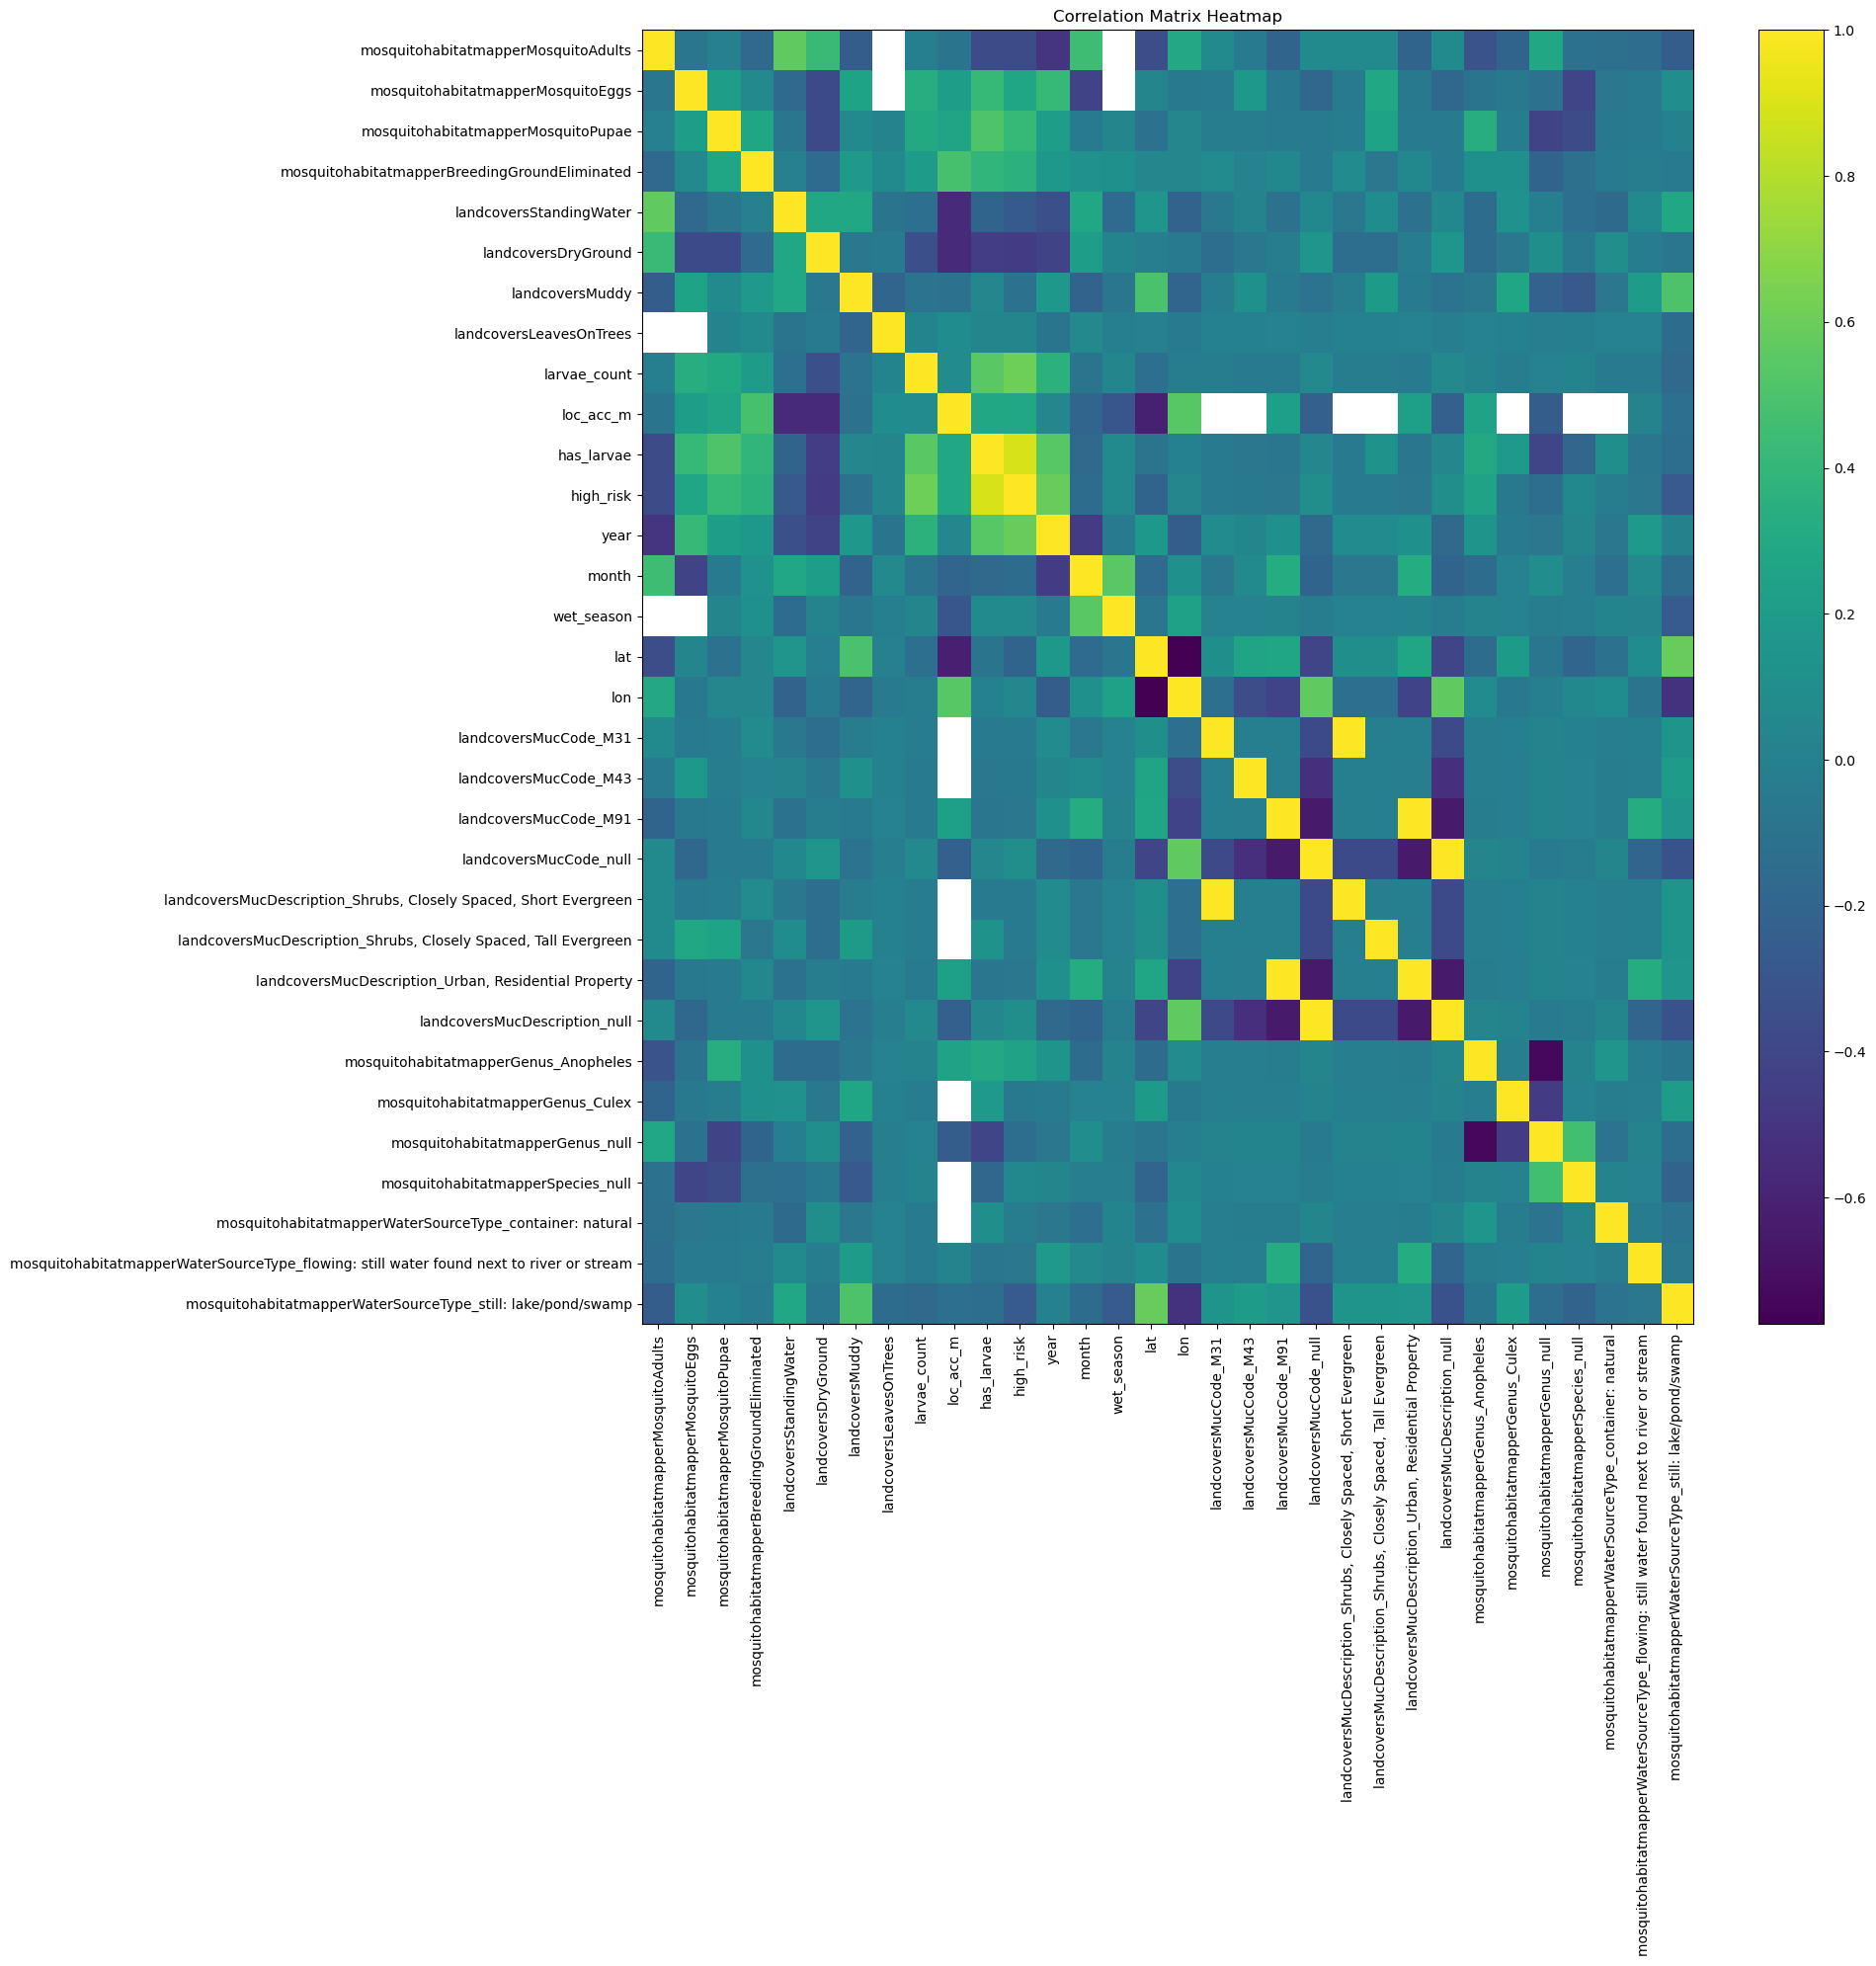

In [55]:
plt.figure(figsize=(20, 20))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

In [56]:
corr_abs = corr_matrix.abs()

# mask upper triangle + diagonal so you only keep each pair once
mask = np.triu(np.ones_like(corr_abs, dtype=bool))
corr_filtered = corr_abs.mask(mask)

top_pairs = (
    corr_filtered.stack()
    .sort_values(ascending=False)
    .head(20)
)

top_pairs

landcoversMucDescription_null                                     landcoversMucCode_null                                  1.000000
landcoversMucDescription_Shrubs, Closely Spaced, Short Evergreen  landcoversMucCode_M31                                   1.000000
landcoversMucDescription_Urban, Residential Property              landcoversMucCode_M91                                   1.000000
high_risk                                                         has_larvae                                              0.893959
lon                                                               lat                                                     0.773190
mosquitohabitatmapperGenus_null                                   mosquitohabitatmapperGenus_Anopheles                    0.736689
landcoversMucDescription_null                                     landcoversMucCode_M91                                   0.647129
landcoversMucCode_null                                            landcoversMucCode

In [65]:
corr_matrix.columns

Index(['mosquitohabitatmapperMosquitoAdults',
       'mosquitohabitatmapperMosquitoEggs',
       'mosquitohabitatmapperMosquitoPupae',
       'mosquitohabitatmapperBreedingGroundEliminated',
       'landcoversStandingWater', 'landcoversDryGround', 'landcoversMuddy',
       'landcoversLeavesOnTrees', 'larvae_count', 'loc_acc_m', 'has_larvae',
       'high_risk', 'year', 'month', 'wet_season', 'lat', 'lon',
       'landcoversMucCode_M31', 'landcoversMucCode_M43',
       'landcoversMucCode_M91', 'landcoversMucCode_null',
       'landcoversMucDescription_Shrubs, Closely Spaced, Short Evergreen',
       'landcoversMucDescription_Shrubs, Closely Spaced, Tall Evergreen',
       'landcoversMucDescription_Urban, Residential Property',
       'landcoversMucDescription_null', 'mosquitohabitatmapperGenus_Anopheles',
       'mosquitohabitatmapperGenus_Culex', 'mosquitohabitatmapperGenus_null',
       'mosquitohabitatmapperSpecies_null',
       'mosquitohabitatmapperWaterSourceType_container: natura

In [66]:
df_corr = df_encoded.copy()

target = "mosquitohabitatmapperLarvaeCount"
df_corr[target] = pd.to_numeric(df_corr[target], errors="coerce")  # convert strings -> numbers

# choose numeric columns only (optional but makes it explicit)
df_corr_num = df_corr.select_dtypes(include="number")

corr_matrix = df_corr_num.corr()

In [67]:
top_larvae_corr = (
    corr_matrix[target]
    .drop(labels=[target])
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

top_larvae_corr.head(25)

larvae_count                                     1.000000
high_risk                                        0.584497
has_larvae                                       0.516538
landcoversDryGround                             -0.356289
year                                             0.334907
mosquitohabitatmapperMosquitoEggs                0.334884
landcoversStandingWater                         -0.274052
mosquitohabitatmapperMosquitoPupae               0.273056
month                                           -0.213925
lat                                             -0.179252
loc_acc_m                                        0.176165
landcoversMuddy                                 -0.142738
mosquitohabitatmapperBreedingGroundEliminated    0.135658
landcoversLeavesOnTrees                          0.036029
lon                                              0.016537
mosquitohabitatmapperMosquitoAdults             -0.008238
wet_season                                            NaN
Name: mosquito

In [68]:
target = "mosquitohabitatmapperLarvaeCount"

top_larvae_corr = (
    corr_matrix[target]
    .drop(target)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

top_larvae_corr.head(25)

larvae_count                                     1.000000
high_risk                                        0.584497
has_larvae                                       0.516538
landcoversDryGround                             -0.356289
year                                             0.334907
mosquitohabitatmapperMosquitoEggs                0.334884
landcoversStandingWater                         -0.274052
mosquitohabitatmapperMosquitoPupae               0.273056
month                                           -0.213925
lat                                             -0.179252
loc_acc_m                                        0.176165
landcoversMuddy                                 -0.142738
mosquitohabitatmapperBreedingGroundEliminated    0.135658
landcoversLeavesOnTrees                          0.036029
lon                                              0.016537
mosquitohabitatmapperMosquitoAdults             -0.008238
wet_season                                            NaN
Name: mosquito

In [71]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

df_reg = df_encoded.copy()

# make sure larvae is numeric first
df_reg["mosquitohabitatmapperLarvaeCount"] = pd.to_numeric(
    df_reg["mosquitohabitatmapperLarvaeCount"], errors="coerce"
)

df_reg = df_reg.dropna(subset=["mosquitohabitatmapperLarvaeCount"])

df_reg["log_larvae"] = np.log1p(df_reg["mosquitohabitatmapperLarvaeCount"])

model = smf.ols(
    "log_larvae ~ landcoversDryGround + landcoversStandingWater + landcoversMuddy + month + year",
    data=df_reg
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_larvae   R-squared:                       0.456
Model:                            OLS   Adj. R-squared:                  0.433
Method:                 Least Squares   F-statistic:                     19.14
Date:                Sat, 31 Jan 2026   Prob (F-statistic):           8.67e-14
Time:                        16:50:07   Log-Likelihood:                -200.72
No. Observations:                 120   AIC:                             413.4
Df Residuals:                     114   BIC:                             430.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                -

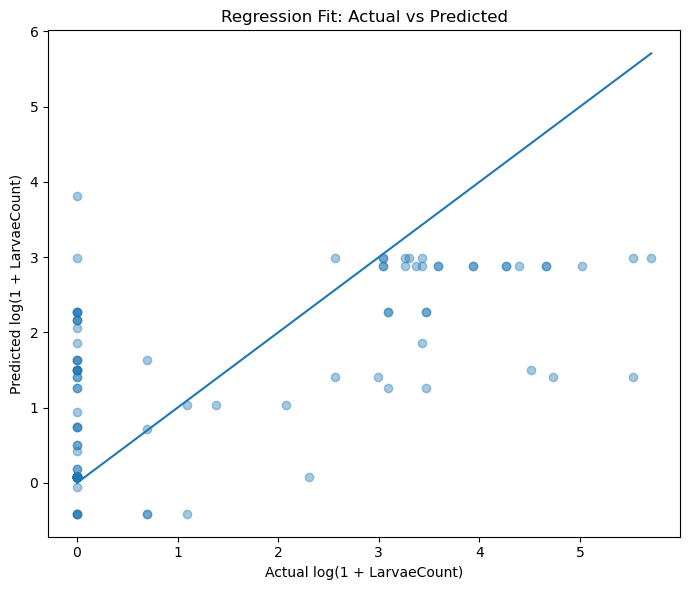

In [72]:
df_reg["pred_log_larvae"] = model.predict(df_reg)

plt.figure(figsize=(7, 6))
plt.scatter(df_reg["log_larvae"], df_reg["pred_log_larvae"], alpha=0.4)
plt.xlabel("Actual log(1 + LarvaeCount)")
plt.ylabel("Predicted log(1 + LarvaeCount)")
plt.title("Regression Fit: Actual vs Predicted")
plt.plot([df_reg["log_larvae"].min(), df_reg["log_larvae"].max()],
         [df_reg["log_larvae"].min(), df_reg["log_larvae"].max()])
plt.tight_layout()
plt.show()
     

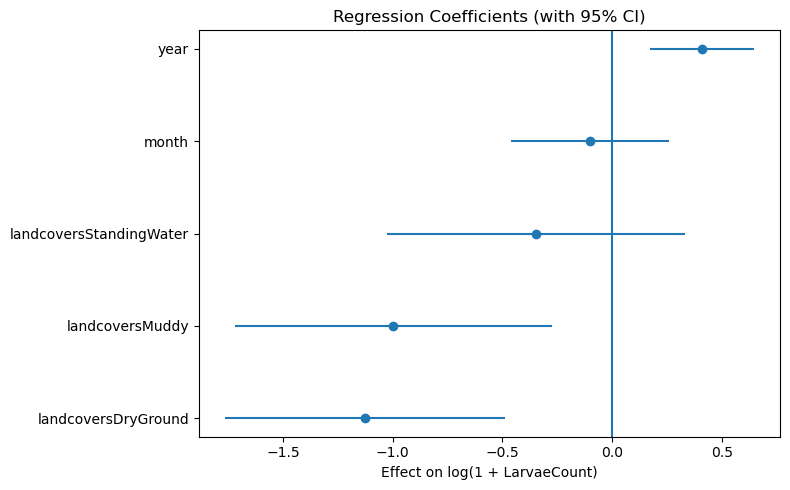

In [73]:
params = model.params
conf = model.conf_int()
conf.columns = ["low", "high"]

coef_df = pd.DataFrame({
    "coef": params,
    "low": conf["low"],
    "high": conf["high"]
}).drop("Intercept", errors="ignore")

coef_df = coef_df.sort_values("coef")

plt.figure(figsize=(8, 5))
plt.errorbar(
    coef_df["coef"],
    range(len(coef_df)),
    xerr=[coef_df["coef"] - coef_df["low"], coef_df["high"] - coef_df["coef"]],
    fmt="o"
)
plt.yticks(range(len(coef_df)), coef_df.index)
plt.axvline(0)
plt.title("Regression Coefficients (with 95% CI)")
plt.xlabel("Effect on log(1 + LarvaeCount)")
plt.tight_layout()
plt.show()

In [74]:
fl_data["has_larvae"] = (fl_data["larvae_count"] > 0).astype(int)
fl_data["high_risk"]  = (fl_data["larvae_count"] >= 5).astype(int)

In [29]:
fl_data["year"] = fl_data["measured_at"].dt.year
fl_data["month"] = fl_data["measured_at"].dt.month

fl_data["wet_season"] = fl_data["month"].isin([5,6,7,8,9,10]).astype(int)

In [30]:
fl_data["lat"] = fl_data.geometry_y.y
fl_data["lon"] = fl_data.geometry_y.x

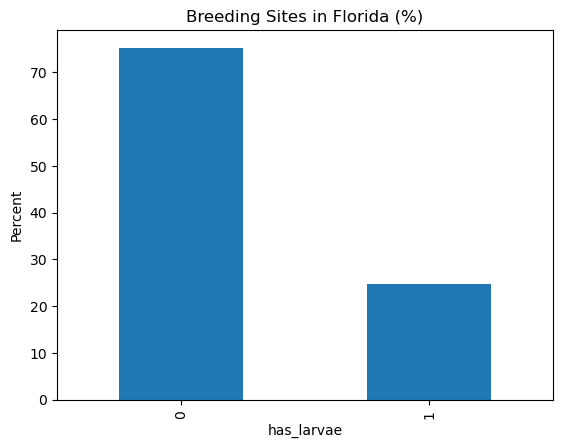

In [31]:
(fl_data["has_larvae"].value_counts(normalize=True) * 100).plot(kind="bar", title="Breeding Sites in Florida (%)")
plt.ylabel("Percent")
plt.show()

In [77]:
total_mosquito = fl_Mos_data["siteId"].nunique()
total_mosquito

269

In [97]:
site_lookup = mos_data[[
    "siteId",
    "mosquitohabitatmapperMeasurementLatitude",
    "mosquitohabitatmapperMeasurementLongitude"
]].drop_duplicates()

In [98]:
fl_data["lat_r"] = fl_data["lat"].round(5)
fl_data["lon_r"] = fl_data["lon"].round(5)

site_lookup["lat_r"] = site_lookup["mosquitohabitatmapperMeasurementLatitude"].round(5)
site_lookup["lon_r"] = site_lookup["mosquitohabitatmapperMeasurementLongitude"].round(5)


In [103]:
total_sites = fl_merged_data["siteId"].nunique()
total_sites

33

In [104]:
missing_land = total_mosquito - total_sites
missing_land

236

In [105]:
missing_pct = missing_land / total_mosquito * 100
missing_pct

87.73234200743495

In [33]:
risk_by_source = fl_data.groupby("mosquitohabitatmapperWaterSourceType")["larvae_count"].mean().sort_values(ascending=False)
risk_by_source.head(10)

mosquitohabitatmapperWaterSourceType
container: artificial                                 16.924242
container: natural                                     2.000000
still: lake/pond/swamp                                 0.162162
flowing: still water found next to river or stream     0.000000
Name: larvae_count, dtype: float64

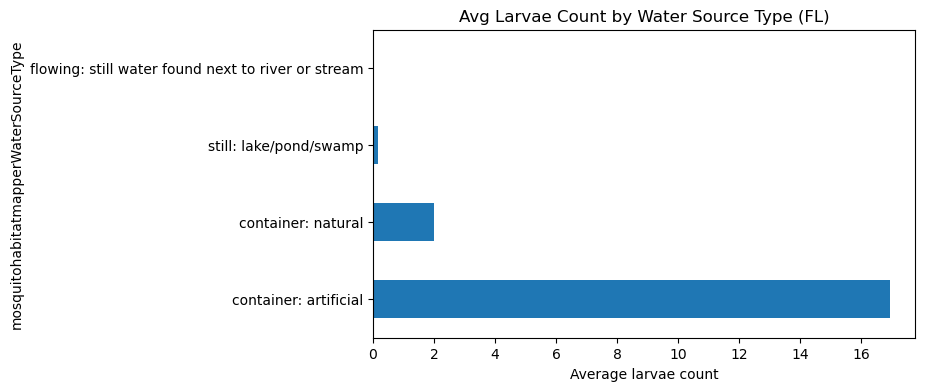

In [34]:
risk_by_source.head(10).plot(kind="barh", title="Avg Larvae Count by Water Source Type (FL)", figsize=(7,4))
plt.xlabel("Average larvae count")
plt.show()

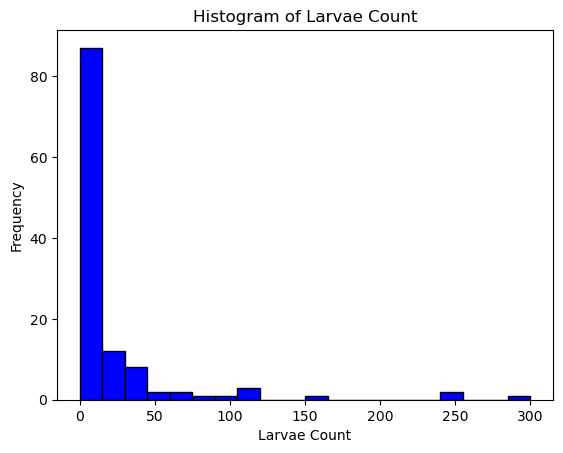

In [76]:
fl_data["mosquitohabitatmapperLarvaeCount"] = pd.to_numeric(fl_data["mosquitohabitatmapperLarvaeCount"], errors="coerce")
fl_data = fl_data.dropna(subset=["mosquitohabitatmapperLarvaeCount"])
plt.hist(fl_data["mosquitohabitatmapperLarvaeCount"], bins=20, color='blue', edgecolor='black')
plt.title("Histogram of Larvae Count")
plt.xlabel("Larvae Count")
plt.ylabel("Frequency")
plt.show()

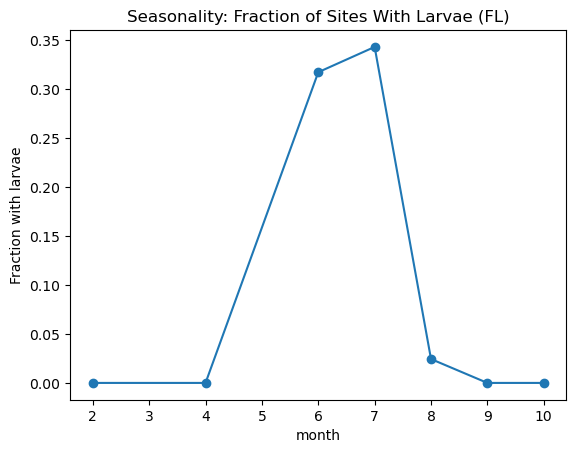

In [36]:
(fl_data.groupby("month")["has_larvae"].mean()).plot(marker="o", title="Seasonality: Fraction of Sites With Larvae (FL)")
plt.ylabel("Fraction with larvae")
plt.show()

In [37]:
(fl_data.groupby("landcoversMucDescription")["has_larvae"].mean()
   .sort_values(ascending=False).head(10))

landcoversMucDescription
Shrubs, Closely Spaced, Tall Evergreen     1.000000
null                                       0.251462
Herbaceous/Grassland, Short Grass          0.000000
Shrubs, Closely Spaced, Short Evergreen    0.000000
Urban, Residential Property                0.000000
Name: has_larvae, dtype: float64

In [38]:
fl_data.groupby("landcoversStandingWater")["has_larvae"].mean()

landcoversStandingWater
0    0.320388
1    0.146667
Name: has_larvae, dtype: float64

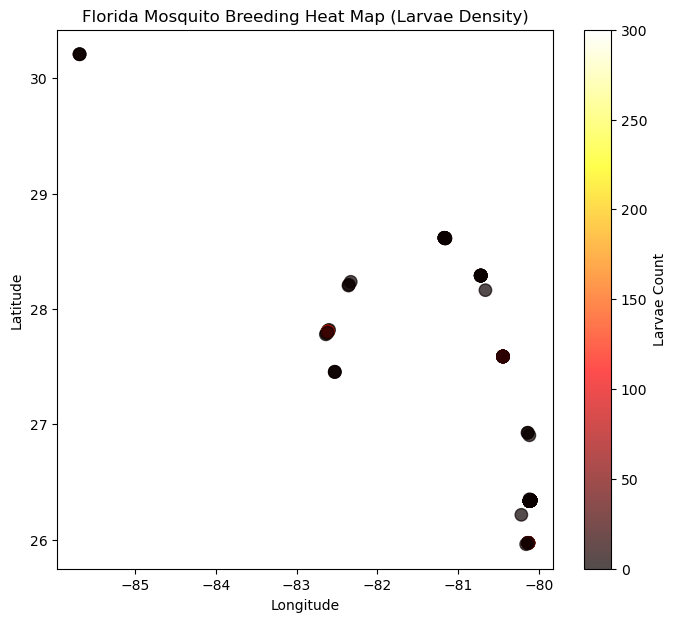

In [40]:
plt.figure(figsize=(8,7))
plt.scatter(fl_data["lon"], fl_data["lat"], c=fl_data["larvae_count"], cmap="hot", s=80, alpha=0.7)
plt.colorbar(label="Larvae Count")
plt.title("Florida Mosquito Breeding Heat Map (Larvae Density)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.show()

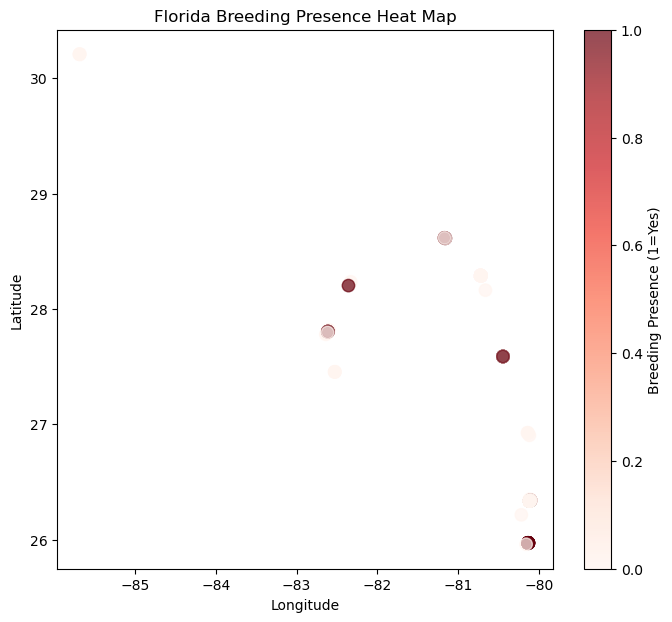

In [41]:
plt.figure(figsize=(8,7))
plt.scatter(fl_data["lon"], fl_data["lat"], c=fl_data["has_larvae"], cmap="Reds", s=80, alpha=0.7)
plt.colorbar(label="Breeding Presence (1=Yes)")
plt.title("Florida Breeding Presence Heat Map")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.show()

In [43]:
corr_df = fl_data[[
    "larvae_count",
    "has_larvae",
    "high_risk",
    "wet_season",
    "mosquitohabitatmapperBreedingGroundEliminated",
    "landcoversStandingWater",
    "landcoversDryGround",
    "landcoversMuddy",
    "landcoversLeavesOnTrees",
    "loc_acc_m"
]].fillna(0)

corr = corr_df.corr()

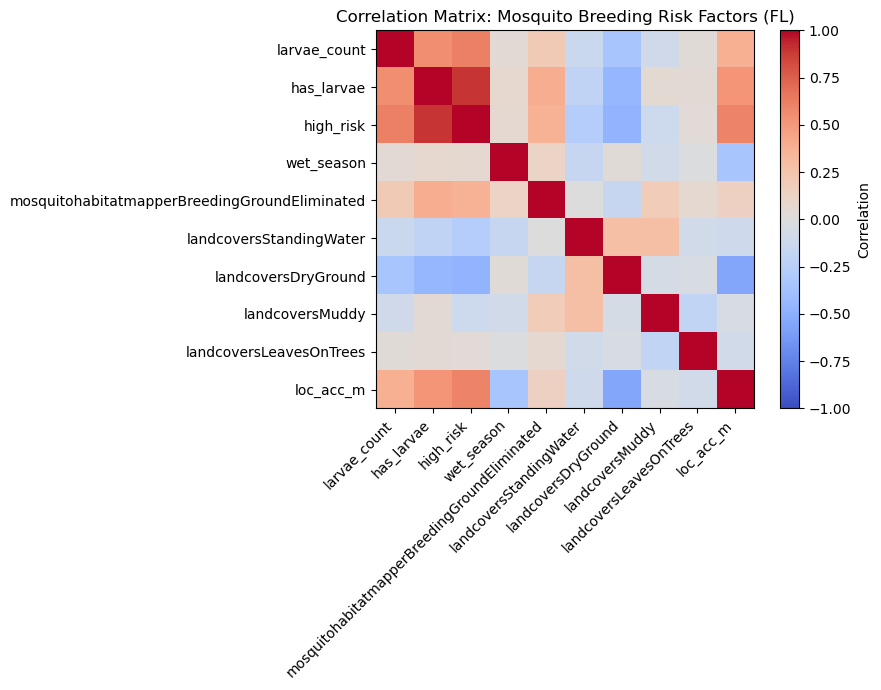

In [44]:
plt.figure(figsize=(9,7))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix: Mosquito Breeding Risk Factors (FL)")
plt.tight_layout()
plt.show()

In [47]:
states_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
states = gpd.read_file(states_url).to_crs("EPSG:4326")

In [48]:
states.columns

Index(['id', 'name', 'density', 'geometry'], dtype='str')

In [49]:
florida_poly = states[states["name"] == "Florida"]

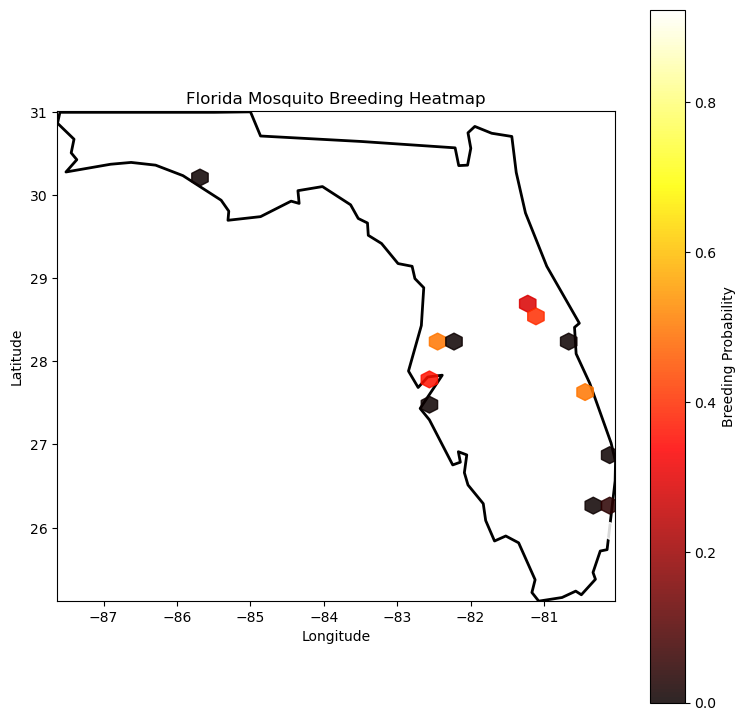

In [52]:
fig, ax = plt.subplots(figsize=(9,9))

# Florida outline
florida_poly.plot(ax=ax, color="white", edgecolor="black", linewidth=2)

# Heatmap (breeding probability)
hb = ax.hexbin(
    fl_data["lon"], fl_data["lat"],
    C=fl_data["has_larvae"],
    reduce_C_function=np.mean,
    gridsize=25,
    cmap="hot",
    mincnt=1,
    alpha=0.85
)

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Breeding Probability")

# Zoom to Florida
minx, miny, maxx, maxy = florida_poly.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title("Florida Mosquito Breeding Heatmap")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()